You've been iterating on a prompt for a **support ticket classifier** — a backend system that routes incoming customer requests into one of four queues: `BILLING`, `TECHNICAL`, `ACCOUNT`, or `GENERAL`. Your first pass was rough, so you've tried eight different formulations: a minimal baseline, a role-framed variant, one with explicit category definitions, two few-shot variants (1-example and 3-example), a chain-of-thought approach, one that returns JSON, and one with negative framing ("do *not* confuse BILLING with ACCOUNT").

After running the eval on 40 labeled tickets with a local Ollama model (`gemma3:1b`), the natural thing to do is compute mean accuracy per prompt and pick the winner. Let's do that.

prompt_id
P0_baseline            45.0
P1_role                42.5
P2_definitions         45.0
P3_few_shot_1          62.5
P4_few_shot_3          65.0
P5_chain_of_thought    55.0
P6_json_output         67.5
P7_negative_framing    37.5


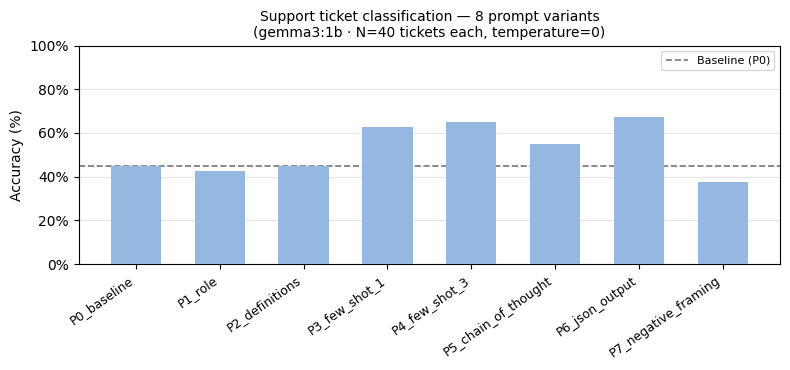

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Load eval results.
# Columns: prompt_id, input_id, ticket, category, output, predicted, correct
df = pd.read_csv("support_ticket_eval.csv")

PROMPTS = [
    "P0_baseline", "P1_role", "P2_definitions",
    "P3_few_shot_1", "P4_few_shot_3",
    "P5_chain_of_thought", "P6_json_output", "P7_negative_framing",
]

# Mean accuracy per prompt
summary = (
    df.groupby("prompt_id")["correct"]
    .mean()
    .loc[PROMPTS]
    .rename("accuracy")
    .to_frame()
    .assign(pct=lambda d: (d["accuracy"] * 100).round(1))
)
print(summary["pct"].to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(range(len(PROMPTS)), summary["pct"], color="#94b8e0", width=0.6, zorder=3)
ax.axhline(
    summary.loc["P0_baseline", "pct"],
    color="#777", lw=1.2, ls="--", label="Baseline (P0)"
)
ax.set_xticks(range(len(PROMPTS)))
ax.set_xticklabels(PROMPTS, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title(
    "Support ticket classification — 8 prompt variants\n"
    "(gemma3:1b · N=40 tickets each, temperature=0)",
    fontsize=10
)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.35, zorder=0)
plt.tight_layout()
plt.show()

## The multiple comparisons problem

The scoreboard looks decisive. `P6_json_output` leads at **67.5%**, `P7_negative_framing` tanks at **37.5%** — a 30-point spread. Few-shot examples help (P3: 62.5%, P4: 65%). Chain-of-thought lands in the middle at 55%. And just adding a role persona alone (`P1_role`) somehow *hurt* by 2.5 points.

But before declaring a winner, there's a problem: you just ran **8 prompt variants on the same 40 tickets.** Every additional comparison you add inflates your risk of a false positive — of calling something "the winner" when it's just lucky sampling noise. With 8 prompts and 28 possible pairwise comparisons, the chance of at least one spurious "significant" result at α = 0.05 is roughly:

```
P(≥1 false positive) = 1 − (1 − 0.05)^28 ≈ 76%
```

Even in the simpler framing of comparing each of 7 variants to a single baseline (7 tests):

```
P(≥1 false positive) = 1 − (1 − 0.05)^7 ≈ 30%
```

To see how this plays out in practice, let's run a simulation. We'll ask: if all 8 prompts were *equally good* — same true accuracy, just different samples — how large a spread between the best and worst would we typically see on 40 tickets?

In [2]:
rng_sim = np.random.default_rng(0)

N_PROMPTS = 8
N_TICKETS = 40
N_SIM = 10_000
TRUE_RATE = 0.55  # all 8 prompts equally good

# For each of 10,000 simulated eval runs, draw binary scores for all 8 prompts
scores_sim = rng_sim.binomial(1, TRUE_RATE, size=(N_SIM, N_PROMPTS, N_TICKETS))
means_sim = scores_sim.mean(axis=2)  # (N_SIM, N_PROMPTS)

# Spread between the best and worst prompt in each run
spreads = means_sim.max(axis=1) - means_sim.min(axis=1)

p50, p90, p95 = np.percentile(spreads, [50, 90, 95])
our_spread = 0.675 - 0.375  # P6_json_output vs P7_negative_framing

print(f"Simulation: {N_PROMPTS} equally-good prompts · true rate = {TRUE_RATE:.0%} · N = {N_TICKETS} tickets")
print(f"Results across {N_SIM:,} simulated eval runs:")
print()
print(f"  Typical (median) best-vs-worst spread:  {p50:.1%}")
print(f"  Spread exceeded in 10% of runs:         {p90:.1%}")
print(f"  Spread exceeded in  5% of runs:         {p95:.1%}")
print()
print(f"  Our observed best-vs-worst spread:      {our_spread:.1%}  (P6 vs P7)")
p_as_extreme = (spreads >= our_spread).mean()
print(f"  P(spread ≥ observed | all equal):       {p_as_extreme:.1%}")
print()
# Rank-winner inflation
top_means = means_sim.max(axis=1)
print(f"  Expected sample accuracy of the naive 'winner':  {top_means.mean():.1%}")
print(f"  True accuracy of every prompt:                   {TRUE_RATE:.1%}")
print(f"  Winner-inflation from always picking the top:   +{top_means.mean() - TRUE_RATE:.1%}")

Simulation: 8 equally-good prompts · true rate = 55% · N = 40 tickets
Results across 10,000 simulated eval runs:

  Typical (median) best-vs-worst spread:  22.5%
  Spread exceeded in 10% of runs:         30.0%
  Spread exceeded in  5% of runs:         32.5%

  Our observed best-vs-worst spread:      30.0%  (P6 vs P7)
  P(spread ≥ observed | all equal):       11.8%

  Expected sample accuracy of the naive 'winner':  66.1%
  True accuracy of every prompt:                   55.0%
  Winner-inflation from always picking the top:   +11.1%


With N=40, the typical best-vs-worst spread across 8 equally-good prompts is already **~22 percentage points** — just from sampling noise. Our observed 30-point spread is not dramatically unusual. And when you always pick the highest-scoring prompt, selection bias inflates its apparent accuracy by several points relative to its true performance.

## Correcting for multiple comparisons with Holm–Bonferroni

The standard fix is **Holm–Bonferroni correction** (usually just "Holm correction"). When you run _k_ hypothesis tests simultaneously, Holm correction adjusts each test's threshold to keep your *family-wise error rate* — the probability of making even one false discovery across all tests — bounded at α = 0.05.

It works by sorting your _k_ p-values from smallest to largest, then checking each one against a progressively relaxed threshold: α/k, α/(k−1), α/(k−2), …, α/1. The first p-value that fails its threshold stops the procedure. This is strictly more powerful than plain Bonferroni (which applies α/k to every test), while providing the same strong error control.

`promptstats` applies Holm correction automatically when you pass `correction="holm"` to `compare_prompts`. Since our scores are binary (pass/fail), it selects the `bayes_binary` method automatically — which our simulation studies show is better calibrated than a plain bootstrap at small sample sizes.

> **Holm vs. FDR?** The alternative, `correction="fdr_bh"` (Benjamini–Hochberg), controls the *false discovery rate* rather than the *family-wise* error rate. FDR is less conservative and favored when you have many comparisons and can tolerate a small fraction of false positives. Holm is the right choice here: we're making a deployment decision, and we want to be sure before calling any prompt the winner.

Let's run the full analysis:

Prompt                         Accuracy  95% CI                  Tier
----------------------------------------------------------------------
P0_baseline                      45.0%  [30.7%, 60.2%]    top
P1_role                          42.5%  [28.5%, 57.8%]    lower
P2_definitions                   45.0%  [30.7%, 60.2%]    top
P3_few_shot_1                    62.5%  [47.0%, 75.8%]    top
P4_few_shot_3                    65.0%  [49.5%, 77.9%]    top
P5_chain_of_thought              55.0%  [39.8%, 69.3%]    top
P6_json_output                   67.5%  [52.0%, 79.9%]    top
P7_negative_framing              37.5%  [24.2%, 53.0%]    lower


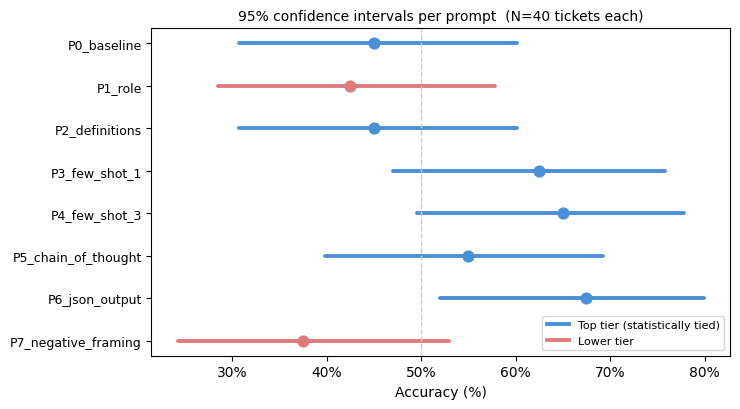

In [3]:
import promptstats as pstats

# One score array per prompt (40 binary values each)
scores = {
    p: df[df["prompt_id"] == p]["correct"].tolist()
    for p in PROMPTS
}

# compare_prompts runs all pairwise comparisons with Holm correction.
report = pstats.compare_prompts(
    scores,
    correction="holm",
    rng=np.random.default_rng(42),
)

# --- Per-prompt confidence intervals ---
print(f"{'Prompt':<28}  {'Accuracy':>9}  {'95% CI':<22}  Tier")
print("-" * 70)
for p in PROMPTS:
    s = report.model_stats[p]
    tier = "top" if p in report.top_tier else "lower"
    print(f"{p:<28}  {s.mean:>8.1%}  [{s.ci_low:.1%}, {s.ci_high:.1%}]    {tier}")

# --- Forest plot ---
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for i, p in enumerate(reversed(PROMPTS)):
    s = report.model_stats[p]
    color = "#4a90d9" if p in report.top_tier else "#e07b7b"
    ax.plot([s.ci_low * 100, s.ci_high * 100], [i, i],
            color=color, lw=2.8, solid_capstyle="round")
    ax.scatter([s.mean * 100], [i], color=color, s=60, zorder=5)

ax.axvline(50, color="#ccc", lw=1, ls="--")
ax.set_yticks(range(len(PROMPTS)))
ax.set_yticklabels(list(reversed(PROMPTS)), fontsize=9)
ax.set_xlabel("Accuracy (%)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("95% confidence intervals per prompt  (N=40 tickets each)", fontsize=10)
ax.legend(handles=[
    Line2D([0], [0], color="#4a90d9", lw=2.8, label="Top tier (statistically tied)"),
    Line2D([0], [0], color="#e07b7b", lw=2.8, label="Lower tier"),
], fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

In [4]:
report.summary()

 PROMPTS COMPARISON 
8 prompts | 40 inputs | method=bayes_binary | correction=holm | CI=95%

--- Pairwise Comparisons (lowest p-value first) ---
  Friedman omnibus: χ²(7) = 31.634, p = 4.749e-05***
  axis: [-0.864, +0.864]  (· ±1σ, ─ CI, ● mean, │ zero)
  Pair                             Interval Plot                                 Mean    CI Low   CI High     r_rb   p (boot)   p (wsr)   p (nem)
  P1_role vs P6_json_output            ······────●───··│····                  -0.2500   -0.4150   -0.1146   -1.000    0.0168*  0.04383*    0.6024
  P6_json_output vs P7_negative_f…               ······│··────●────·········  +0.3000   +0.1173   +0.4658    0.750    0.0486*   0.07289    0.3571
  P2_definitions vs P6_json_output      ······────●───·│·····                 -0.2250   -0.3923   -0.0898   -1.000      0.052   0.07289    0.7239
  P2_definitions vs P4_few_shot_3        ······───●───·│·····                 -0.2000   -0.3611   -0.0782   -1.000      0.065    0.1127    0.8284
  P4_few_shot_3 

## Reading the results

The executive summary groups prompts into tiers based on which pairwise differences survive Holm correction.

**Group #1 (tied at the top):** `P6_json_output`, `P4_few_shot_3`, `P3_few_shot_1`, `P5_chain_of_thought`, `P0_baseline`, `P2_definitions`. These six prompts — spanning raw accuracies from **45.0% to 67.5%** — are statistically *indistinguishable* from one another at N=40. The confidence intervals are ~30 percentage points wide and overlap heavily. After Holm correction, no pairwise difference within this group survives.

**Group #2 (confirmed underperformers):** `P1_role` (42.5%) and `P7_negative_framing` (37.5%) are significantly *worse* than the top tier. This is the most actionable finding: two common prompt patterns genuinely hurt performance on this model. A role-only persona with no other guidance seems to confuse `gemma3:1b`, and negative/contrastive framing ("do NOT confuse BILLING with ACCOUNT") backfires badly.

**What happened to the "winner"?** `P6_json_output` at 67.5% looked like a clear leader. But its 95% CI is `[52.0%, 79.9%]`, and `P0_baseline`'s is `[30.7%, 60.2%]` — these intervals overlap by about 8 percentage points. With N=40, you simply don't have the resolution to confirm whether the 22-point gap between them is real. To reliably detect a 20-point gap at 80% power, you'd need roughly **N=80–100 tickets**. To detect a 10-point gap, closer to **N=250+**.

The raw bar chart told a story. A lot of it was noise.

> **Honest reporting template.** *"Among the six top-tier prompts, differences are within sampling noise at N=40. `P6_json_output` has the highest point estimate (67.5%) and is a reasonable provisional choice, but the margin over baseline is not statistically confirmed. `P1_role` and `P7_negative_framing` are confirmed underperformers and should be dropped. Re-run the eval with ~150 tickets to resolve the top-tier ranking."*